In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Ensemble Methods

## Dataset

The dataset was generated from a deep learning model trained on the Obesity or CVD risk dataset. 
https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster

The data consist of the estimation of obesity levels in people from the countries of Mexico, Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition , data was collected using a web platform with a survey where anonymous users answered each question, then the information was processed obtaining 17 attributes and 2111 records.
The attributes related with eating habits are: Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS)
variables obtained :
Gender, Age, Height and Weight.

NObesity values are:

- Underweight Less than 18.5
- Normal 18.5 to 24.9
- Overweight 25.0 to 29.9
- Obesity I 30.0 to 34.9
- Obesity II 35.0 to 39.9
- Obesity III Higher than 40

In [39]:
df = pd.read_csv("./Data/playground-series-s4e2/train.csv")
df

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [41]:
df.nunique()

id                                20758
Gender                                2
Age                                1703
Height                             1833
Weight                             1979
family_history_with_overweight        2
FAVC                                  2
FCVC                                934
NCP                                 689
CAEC                                  4
SMOKE                                 2
CH2O                               1506
SCC                                   2
FAF                                1360
TUE                                1297
CALC                                  3
MTRANS                                5
NObeyesdad                            7
dtype: int64

In [42]:
# Split the data into features and target variable

target = "NObeyesdad"
y = df[target]
X = df.drop(columns=[target, "id"])

In [43]:
# Convert categorical variables to numeric using one-hot encoding

X[X.select_dtypes('object').columns] = X.select_dtypes('object').apply(pd.Categorical)
X = pd.get_dummies(X, drop_first=True).astype(float)

In [44]:
# Convert labels to numeric using LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
np.unique(y), le.classes_

(array([0, 1, 2, 3, 4, 5, 6]),
 array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
        'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
        'Overweight_Level_II'], dtype=object))

In [45]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16606, 22), (4152, 22), (16606,), (4152,))

### Dummy Classifier

In [46]:
from sklearn.dummy import DummyClassifier

model = DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.06282803118308164

### Random Forest
A random forest uses bagging with Decision Trees

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8857199603747906

In [51]:
import seaborn as sns

Text(0.5, 0, 'Importance')

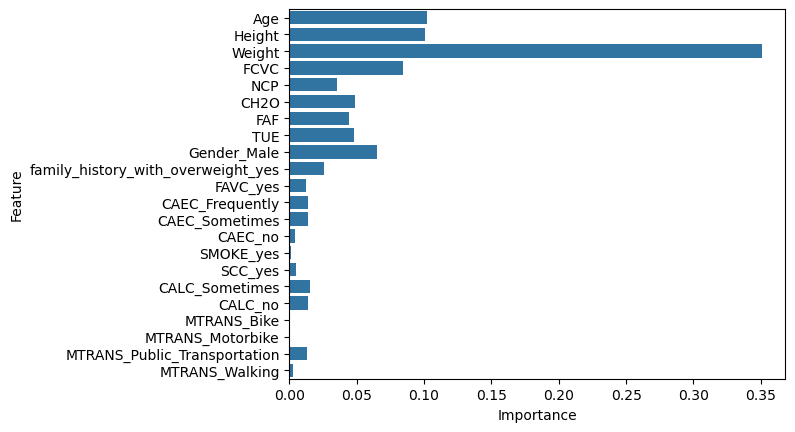

In [58]:
sns.barplot(
    x=model.feature_importances_, 
    y=X.columns, 
)
plt.ylabel("Feature")
plt.xlabel("Importance")

### Bagging
You can use a bagging wrapper with any sklearn-like estimator, e.g., 10 SVMs

In [17]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

model = BaggingClassifier(
    estimator=SVC(),
    n_estimators=10, 
    random_state=0
)

In [16]:
model.fit(X_train, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=0.001, batch_size=32, hidden_layer_sizes=(32,),
              random_state=42, solver='sgd')

In [18]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.7075605289919797

### Extra Trees

In [1]:
from sklearn.ensemble import ExtraTreesClassifier

### Adaptive Boosting
Estimator for boosting need to support sample weighting, e.g., decision trees

In [19]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=0)

In [20]:
model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                   random_state=0)

In [21]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8438156747536851

### Gradient Boosting

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=0)

In [25]:
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=0)

In [26]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.9044497558170499

### LGBM
LightGBM, short for Light Gradient-Boosting Machine, is a separate library, but works just as sklearn

In [29]:
# !pip install lightgbm

In [59]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=0)

In [60]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 22
[LightGBM] [Info] Start training from score -2.117117
[LightGBM] [Info] Start training from score -1.911230
[LightGBM] [Info] Start training from score -1.948141
[LightGBM] [Info] Start training from score -1.857720
[LightGBM] [Info] Start training from score -1.633574
[LightGBM] [Info] Start training from score -2.145531
[LightGBM] [Info] Start training from score -2.112625


LGBMClassifier(random_state=0)

In [61]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.9052818650203321

Text(0.5, 0, 'Importance')

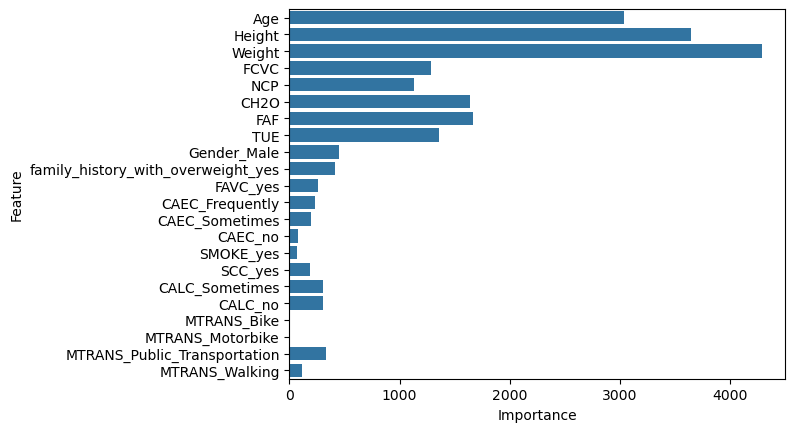

In [63]:
sns.barplot(
    x=model.feature_importances_, 
    y=X.columns, 
)
plt.ylabel("Feature")
plt.xlabel("Importance")

### XGBoost
XGBoost is also a separate library, try it by yourself!

In [ ]:
# !pip install xgboost

In [34]:
from xgboost import XGBClassifier

In [35]:
model = XGBClassifier(random_state=0)

### Catboost
Catboost is another very good one https://catboost.ai/docs/en/installation/python-installation-method-pip-install


# Exercise
Use one bagging and one boosting approach to predict the Age as a target, evaluate it using the MAE

In [26]:
target = "Age"
y = df[target]
X = df.drop(columns=[target, "id"])

In [27]:
# Convert categorical variables to numeric using one-hot encoding

X[X.select_dtypes('object').columns] = X.select_dtypes('object').apply(pd.Categorical)
X = pd.get_dummies(X, drop_first=True).astype(float)

In [28]:
# Split the data into training and testing sets

In [29]:
# (Optional) test a dummy model to set a baseline performance

In [23]:
# build and evaluate the bagging/boosting model